In [1]:
import sys
from pathlib import Path

# add the project root to Python's module search path so that
# the notebook can import the source code from src/.
project_root = Path.cwd().parent

if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

# Stabilizer Measurement as One-Bit Quantum Phase Estimation

The discussion in this notebook follows IBM Quantum Learning's treatment in *Fundamentals of Quantum Algorithms*, particularly “The phase-estimation procedure” in the *Phase-estimation and factoring* lesson.


Quantum phase estimation (QPE) is a quantum subroutine for estimating the phase associated with an eigenvalue of a unitary operator [1]. Suppose that $U$ is unitary and that $|\psi\rangle$ is an eigenstate of $U$, so that

$$
U|\psi\rangle = e^{2\pi i\phi}|\psi\rangle
$$

for some phase $\phi \in [0,1)$. The goal of QPE is to estimate the value of $\phi$.

In the general QPE procedure, multiple control qubits are used to estimate $\phi$ to a desired number of bits of precision. Controlled powers of $U$ encode information about the phase into the control qubits, and an inverse quantum Fourier transform is then used to decode this phase information.

In this notebook, we are interested in a particularly simple special case: one-bit phase estimation. With only one control qubit, the inverse quantum Fourier transform reduces to a Hadamard gate.

This one-bit setting is sufficient when $U$ has eigenvalues only in $\{+1,-1\}$. Indeed,

$$
+1 = e^{2\pi i \cdot 0},
\qquad
-1 = e^{2\pi i \cdot \frac{1}{2}},
$$

so the corresponding phases are

$$
\phi = 0
\qquad \text{or} \qquad
\phi = \frac{1}{2}.
$$

When the input is an eigenstate of $U$, these two possibilities can therefore be distinguished exactly using a single control qubit.

After establishing the one-bit QPE circuit for the simple example $U=X$, we will apply the same idea to Pauli stabilizer operators. Since every stabilizer generator $S$ satisfies

$$
S^2 = I,
$$

its eigenvalues are also $\pm 1$. If the data state is an eigenstate of $S$, the one-bit phase-estimation procedure determines whether the corresponding eigenvalue is $+1$ or $-1$. More generally, applying the same circuit to an arbitrary data state implements a measurement that projects the state onto the $+1$ or $-1$ eigenspace of $S$.

## 1. The One-Bit QPE Circuit

Suppose that $|\psi\rangle$ is an eigenstate of a unitary operator $U$, with

$$
U|\psi\rangle = e^{2\pi i\phi}|\psi\rangle.
$$

The one-bit QPE circuit uses a single control qubit initialized in the state $|0\rangle$. In the Qiskit circuit below, the data qubit is displayed above the control qubit. Following Qiskit's statevector ordering convention, we write the initial joint state as

$$
|0\rangle \otimes |\psi\rangle.
$$

A Hadamard gate first prepares the control qubit in the state

$$
|+\rangle = \frac{|0\rangle + |1\rangle}{\sqrt{2}},
$$

so that the joint state becomes

$$
\frac{|0\rangle + |1\rangle}{\sqrt{2}}
\otimes |\psi\rangle.
$$

A controlled-$U$ operation then applies $U$ to the data register only when the control qubit is in the state $|1\rangle$. The resulting joint state is

$$
\frac{1}{\sqrt{2}}
\left(
|0\rangle \otimes |\psi\rangle
+
|1\rangle \otimes U|\psi\rangle
\right).
$$

Since

$$
U|\psi\rangle = e^{2\pi i\phi}|\psi\rangle,
$$

this becomes

$$
\frac{|0\rangle + e^{2\pi i\phi}|1\rangle}{\sqrt{2}}
\otimes |\psi\rangle.
$$

Thus, by phase kickback, the eigenvalue of $U$ appears as a relative phase on the control qubit.

Since the inverse quantum Fourier transform on a single qubit is a Hadamard gate, applying a second Hadamard to the control qubit and then measuring it completes the one-bit phase-estimation procedure. The corresponding circuit is shown below.

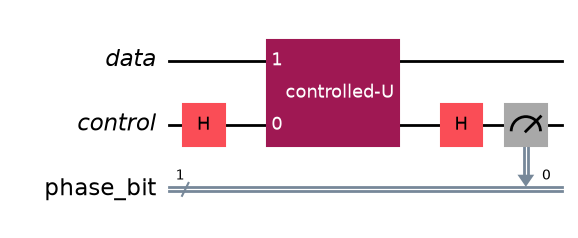

In [2]:
from qiskit.circuit import (
    ClassicalRegister,
    Instruction,
    QuantumCircuit,
    QuantumRegister,
    Qubit,
)

control = QuantumRegister(1, "control")
data = QuantumRegister(1, "data")
phase_bit = ClassicalRegister(1, "phase_bit")

qc = QuantumCircuit(data, control, phase_bit)

# Schematic placeholder for a generic controlled-U operation.
controlled_U = Instruction(
    name="controlled-U",
    num_qubits=2,
    num_clbits=0,
    params=[],
)

qc.h(control[0])
qc.append(controlled_U, [control[0], data[0]])
qc.h(control[0])
qc.measure(control[0], phase_bit[0])

qc.draw("mpl")

Immediately before the final Hadamard, the control qubit is in the state

$$
\frac{|0\rangle + e^{2\pi i\phi}|1\rangle}{\sqrt{2}}.
$$

After applying the Hadamard, the probabilities of measuring $0$ and $1$ are

$$
P(0)=\cos^2(\pi\phi),
\qquad
P(1)=\sin^2(\pi\phi).
$$

For the case of interest in this notebook, the eigenvalue of $U$ is either $+1$ or $-1$. If

$$
U|\psi\rangle=+|\psi\rangle,
$$

then $\phi=0$, so

$$
P(0)=1,
\qquad
P(1)=0.
$$

Therefore, if $|\psi\rangle$ has eigenvalue $+1$ under $U$, measuring the control qubit returns $0$ with certainty.

If instead

$$
U|\psi\rangle=-|\psi\rangle,
$$

then $\phi=\frac{1}{2}$, so

$$
P(0)=0,
\qquad
P(1)=1.
$$

Therefore, if $|\psi\rangle$ has eigenvalue $-1$ under $U$, measuring the control qubit returns $1$ with certainty.

Thus, for a unitary operator with eigenvalues in $\{+1,-1\}$, one-bit QPE distinguishes the two possible eigenvalues exactly when the input is an eigenstate of $U$: measurement outcome $0$ identifies the eigenvalue $+1$, while measurement outcome $1$ identifies the eigenvalue $-1$.

We now verify this explicitly for the simplest Pauli example, $U=X$.

## 2. Example: One-Bit QPE for $U=X$

The Pauli $X$ operator has eigenstates

$$
|+\rangle=\frac{|0\rangle+|1\rangle}{\sqrt{2}},
\qquad
|-\rangle=\frac{|0\rangle-|1\rangle}{\sqrt{2}},
$$

with corresponding eigenvalues

$$
X|+\rangle=+|+\rangle,
\qquad
X|-\rangle=-|-\rangle.
$$

Since the eigenvalues are $+1$ and $-1$, their corresponding phases are $\phi=0$ and $\phi=\frac{1}{2}$, respectively. We therefore expect one-bit QPE to return measurement outcome $0$ for the input state $|+\rangle$ and measurement outcome $1$ for the input state $|-\rangle$.

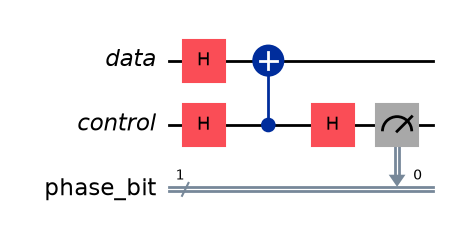

In [3]:
control = QuantumRegister(1, "control")
data = QuantumRegister(1, "data")
phase_bit = ClassicalRegister(1, "phase_bit")

qc = QuantumCircuit(data, control, phase_bit)

# Prepare the +1-eigenstate of U=X
qc.h(data[0])

# 1-bit QPE for X
qc.h(control[0])
qc.cx(control[0], data[0])
qc.h(control[0])
qc.measure(control[0], phase_bit[0])

qc.draw("mpl")

In [4]:
from qiskit_aer import AerSimulator

simulator = AerSimulator()
result = simulator.run(qc, shots=100).result()
counts = result.get_counts()
counts

{'0': 100}

The input state $|+\rangle$ satisfies

$$
X|+\rangle=+|+\rangle,
$$

so its eigenvalue under $X$ is $+1$, corresponding to the phase $\phi=0$. As expected, the control qubit is measured in the state $|0\rangle$ with certainty.

And now the -1 eigenvalue case.

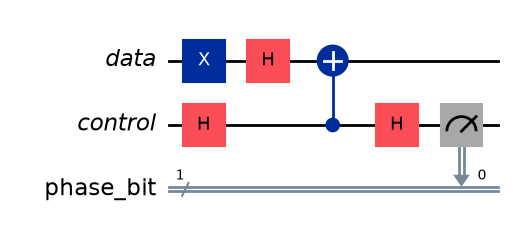

In [5]:
control = QuantumRegister(1, "control")
data = QuantumRegister(1, "data")
phase_bit = ClassicalRegister(1, "phase_bit")

qc = QuantumCircuit(data, control, phase_bit)

# Prepare the -1-eigenstate of U=X
qc.x(data[0])
qc.h(data[0])

# 1-bit QPE for X
qc.h(control[0])
qc.cx(control[0], data[0])
qc.h(control[0])
qc.measure(control[0], phase_bit[0])

qc.draw("mpl")

In [6]:
simulator = AerSimulator()
result = simulator.run(qc, shots=100).result()
counts = result.get_counts()
counts

{'1': 100}

The input state is

$$
|-\rangle = \frac{|0\rangle-|1\rangle}{\sqrt{2}},
$$

which satisfies

$$
X|-\rangle=-|-\rangle.
$$

Thus, the eigenvalue of $X$ is $-1$, corresponding to the phase $\phi=\frac{1}{2}$. The one-bit QPE procedure therefore measures the ancilla in the state $|1\rangle$ with certainty.

## 3. One-Bit QPE for a Multi-Qubit Pauli Operator

The same one-bit phase-estimation procedure applies when $U$ is a multi-qubit Pauli operator. Consider the Steane stabilizer

$$
S_1 = X_0X_1X_2X_3.
$$

Because each Pauli factor satisfies $X_i^2=I$, we have

$$
S_1^2 = I,
$$

so the only possible eigenvalues of $S_1$ are $+1$ and $-1$. Consequently, a single control qubit is sufficient to distinguish the two eigenspaces of $S_1$ through one-bit phase estimation.

The controlled-$S_1$ operation applies $X$ to each of the four data qubits in the support of $S_1$ when the control qubit is in the state $|1\rangle$. It can therefore be implemented using four controlled-$X$ gates, or CNOTs, with the control qubit as the common control.

We first test the procedure using a $+1$ eigenstate of

$$
S_1 = X_0X_1X_2X_3.
$$

The state

$$
|+\rangle^{\otimes 7}
$$

is a $+1$ eigenstate because $X|+\rangle=|+\rangle$. Thus,

$$
S_1|+\rangle^{\otimes 7}=|+\rangle^{\otimes 7},
$$

and we expect the QPE measurement to return $0$ with certainty.

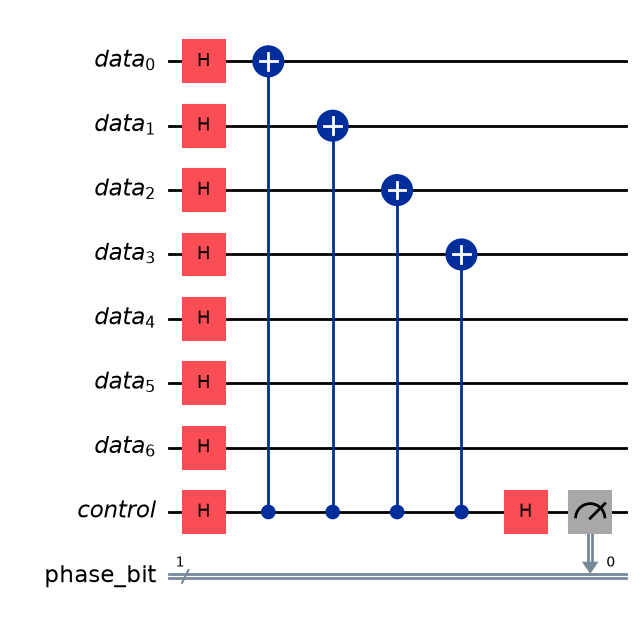

In [7]:
control = QuantumRegister(1, "control")
data = QuantumRegister(7, "data")
phase_bit = ClassicalRegister(1, "phase_bit")

qc = QuantumCircuit(data, control, phase_bit)

# Prepare the data qubits in the +1 eigenstate |+++++++> of S_1
for i in range(7):
    qc.h(data[i])

# 1-bit QPE for S1
qc.h(control[0])

for i in range(4):
    qc.cx(control[0], data[i])

qc.h(control[0])

qc.measure(control[0], phase_bit[0])

qc.draw("mpl")

In [8]:
simulator = AerSimulator()
result = simulator.run(qc, shots=100).result()
counts = result.get_counts()
counts

{'0': 100}

We now repeat the experiment with a $-1$ eigenstate of $S_1$. We prepare $q_0$ in the state $|-\rangle$ and the remaining data qubits in the state $|+\rangle$:

$$
|\psi\rangle
=
|+\rangle|+\rangle|+\rangle|+\rangle|+\rangle|+\rangle|-\rangle,
$$

where the ordering follows Qiskit's tensor-product convention. Since $S_1$ acts on qubits $q_0,\ldots,q_3$,

$$
S_1|\psi\rangle=-|\psi\rangle.
$$

We therefore expect the QPE measurement to return $1$ with certainty.

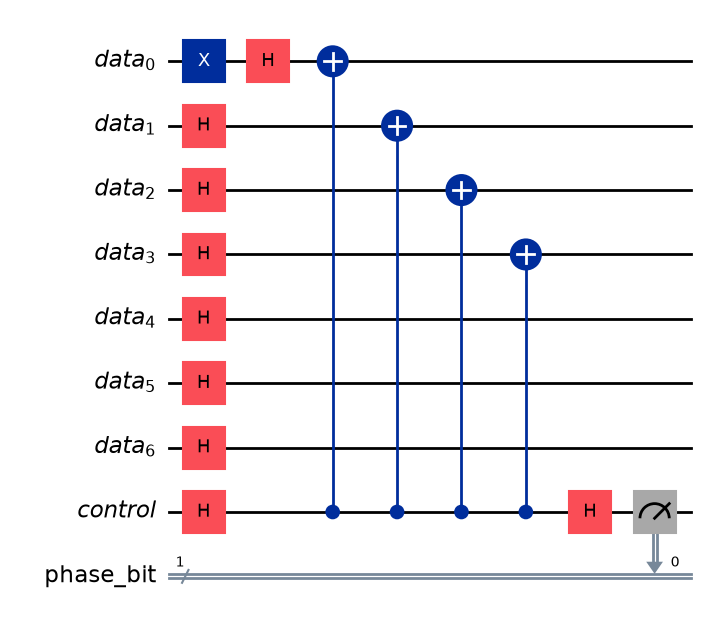

In [9]:
control = QuantumRegister(1, "control")
data = QuantumRegister(7, "data")
phase_bit = ClassicalRegister(1, "phase_bit")

qc = QuantumCircuit(data, control, phase_bit)

# Prepare the data qubits in a -1 eigenstate of S_1
# q_0 = |-> and q_1,...,q_6 = |+>
qc.x(data[0])
for i in range(7):
    qc.h(data[i])

# 1-bit QPE for S1
qc.h(control[0])

for i in range(4):
    qc.cx(control[0], data[i])

qc.h(control[0])

qc.measure(control[0], phase_bit[0])

qc.draw("mpl")

In [10]:
simulator = AerSimulator()
result = simulator.run(qc, shots=100).result()
counts = result.get_counts()
counts

{'1': 100}

These two examples show that the one-bit QPE procedure correctly distinguishes the two eigenspaces of the multi-qubit Pauli operator $S_1$:

$$
\begin{aligned}
S_1|\psi\rangle=+|\psi\rangle
&\quad\Longrightarrow\quad
\text{measurement outcome }0,\\
S_1|\psi\rangle=-|\psi\rangle
&\quad\Longrightarrow\quad
\text{measurement outcome }1.
\end{aligned}
$$

We next compare this QPE circuit with the ancilla-based measurement circuit used to measure the same stabilizer.

## 4. QPE and Ancilla-Based Stabilizer Measurement

We now compare the one-bit QPE circuit for

$$
S_1 = X_0X_1X_2X_3
$$

with the ancilla-based circuit used to measure the same stabilizer in the Steane code.

For one-bit QPE, the circuit consists of a Hadamard on the control qubit, a controlled-$S_1$ operation, a second Hadamard, and a measurement of the control qubit.

Because $S_1$ is a product of Pauli-$X$ operators, the controlled-$S_1$ operation can be implemented as a sequence of CNOT gates, with the control qubit controlling each $X$ operation on the support of $S_1$.

Thus, the QPE circuit has exactly the same gate structure as the ancilla-based measurement circuit for the $X$-type stabilizer $S_1$.

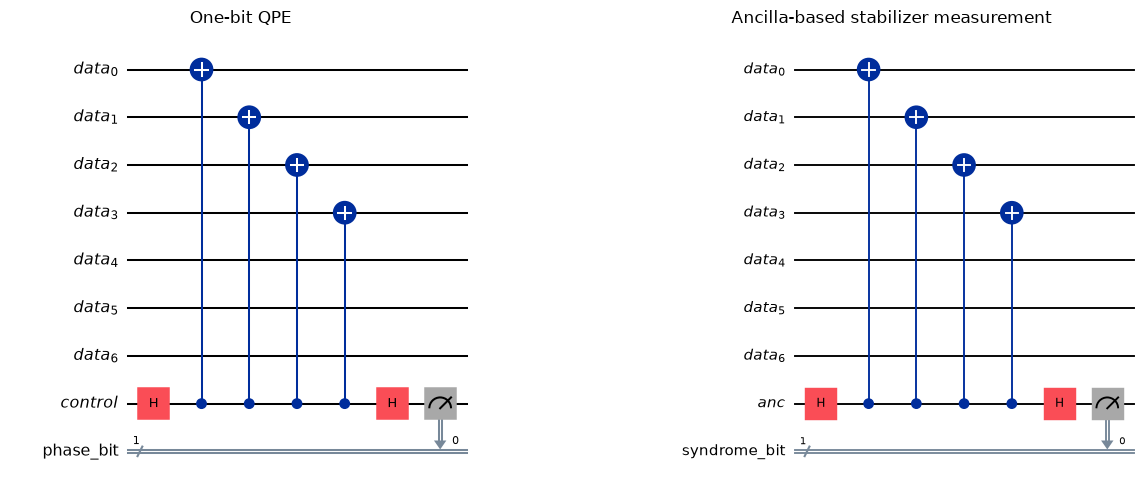

In [11]:
# prepare one-bit QPE circuit for S1
control = QuantumRegister(1, "control")
data_qpe = QuantumRegister(7, "data")
phase_bit = ClassicalRegister(1, "phase_bit")

qc_qpe = QuantumCircuit(data, control, phase_bit)

qc_qpe.h(control[0])

for i in range(4):
    qc_qpe.cx(control[0], data[i])

qc_qpe.h(control[0])

qc_qpe.measure(control[0], phase_bit[0])

# prepare stabilizer measurement circuit for S1 using imported variables and functions
from qiskit.circuit import AncillaRegister

from src.steane import Stabilizers, measure_stabilizer

data_measure = QuantumRegister(7, "data")
ancilla = AncillaRegister(1, "anc")
syndrome_bit = ClassicalRegister(1, "syndrome_bit")

qc_measure = QuantumCircuit(data, ancilla, syndrome_bit)

measure_stabilizer(
    qc_measure,
    data,
    ancilla,
    syndrome_bit,
    Stabilizers[0],
    0,
)

# print the two circuits side-by-side
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

qc_qpe.draw("mpl", ax=axes[0])
axes[0].set_title("One-bit QPE")

qc_measure.draw("mpl", ax=axes[1])
axes[1].set_title("Ancilla-based stabilizer measurement")

plt.tight_layout()
plt.show()

The two circuits are identical gate-for-gate. For the $X$-type stabilizer

$$
S_1 = X_0X_1X_2X_3,
$$

the ancilla-based stabilizer measurement circuit is therefore precisely the one-bit QPE circuit for $U=S_1$.

The measurement outcome identifies the eigenspace of $S_1$ onto which the data state is projected:

$$
\begin{aligned}
\text{outcome }0 &\longleftrightarrow \text{$+1$ eigenspace of }S_1,\\
\text{outcome }1 &\longleftrightarrow \text{$-1$ eigenspace of }S_1.
\end{aligned}
$$

In the context of quantum error correction, this measurement outcome is the corresponding syndrome bit.

## 5. Extension to $Z$-Type Stabilizers

The same one-bit QPE construction applies to the $Z$-type Steane stabilizers as well. Consider, for example,

$$
S_4 = Z_0Z_1Z_2Z_3.
$$

Since $S_4^2=I$, its eigenvalues are again $\pm1$, so a single control qubit is sufficient.

The controlled-$S_4$ operation can be implemented using controlled-$Z$ gates between the control qubit and each data qubit in the support of $S_4$.

The existing Steane-code implementation measures $S_4$ using CZ gates between the ancilla and the data qubits in the support of $S_4$. 

Thus, just as in the $X$-type case, the one-bit QPE circuit and the ancilla-based stabilizer-measurement circuit have the same gate structure. The additional qubit is interpreted as the control qubit in the QPE description and as the measurement ancilla in the stabilizer-measurement description.

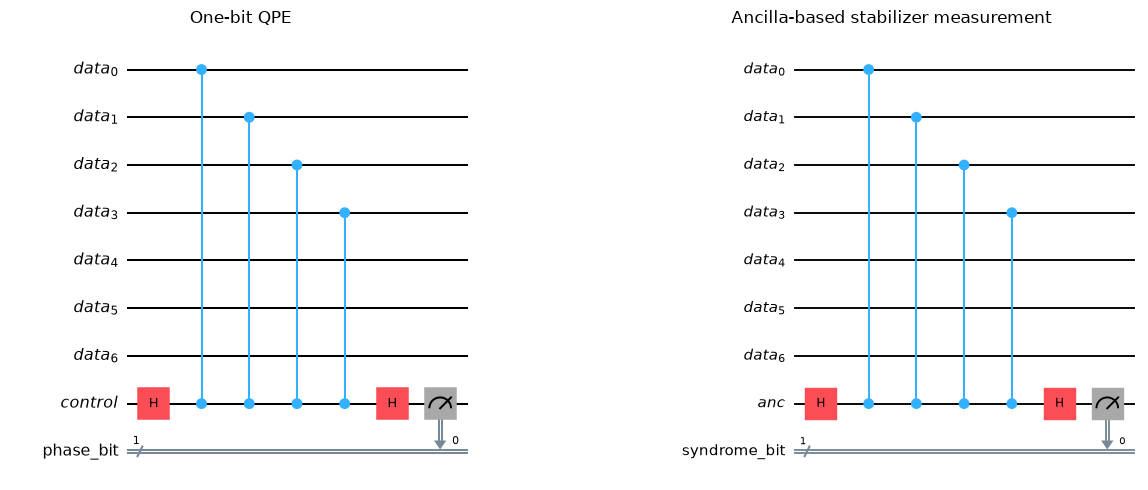

In [12]:
# construct qpe circuit for S4
control = QuantumRegister(1, "control")
data_qpe_z = QuantumRegister(7, "data")
phase_bit = ClassicalRegister(1, "phase_bit")

qc_qpe_z = QuantumCircuit(data_qpe_z, control, phase_bit)

# 1-bit QPE for S_4 = Z_0 Z_1 Z_2 Z_3
qc_qpe_z.h(control[0])

for i in range(4):
    qc_qpe_z.cz(control[0], data_qpe_z[i])

qc_qpe_z.h(control[0])

qc_qpe_z.measure(control[0], phase_bit[0])

# construct ancilla-based stabilizer measurement circuit for S4
from src.steane import Stabilizers, measure_stabilizer

data_measure_z = QuantumRegister(7, "data")
ancilla = AncillaRegister(1, "anc")
syndrome_bit = ClassicalRegister(1, "syndrome_bit")

qc_measure_z = QuantumCircuit(data_measure_z, ancilla, syndrome_bit)

measure_stabilizer(
    qc_measure_z,
    data_measure_z,
    ancilla,
    syndrome_bit,
    Stabilizers[3],
    0,
)

# print the two circuits side-by-side
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

qc_qpe_z.draw("mpl", ax=axes[0])
axes[0].set_title("One-bit QPE")

qc_measure_z.draw("mpl", ax=axes[1])
axes[1].set_title("Ancilla-based stabilizer measurement")

plt.tight_layout()
plt.show()

The $Z$-type example confirms the same correspondence found for $S_1$: ancilla-based measurement of a Steane stabilizer can be viewed as one-bit quantum phase estimation of that stabilizer.

For both $X$-type and $Z$-type stabilizers, the measurement outcome identifies the eigenspace of the stabilizer onto which the data state is projected, and this outcome is the corresponding syndrome bit.

## 6. Syndrome Bits as Phase-Estimation Outcomes

The preceding examples show that one-bit QPE can be used to measure the eigenvalue of each Steane stabilizer. We now connect this observation to the algebraic definition of the syndrome.

Let $|\psi\rangle$ be a code state and let $E$ be a Pauli error. Since $S_i|\psi\rangle=|\psi\rangle,$ and since each Pauli error either commutes or anticommutes with $S_i$, we can write

$$
S_iE=(-1)^{s_i(E)}ES_i,
$$

where $s_i(E)\in\{0,1\}$ is the $i$-th syndrome bit. Applying $S_i$ to the corrupted state $E | \psi \rangle$ gives

$$
\begin{aligned}
S_iE|\psi\rangle
&=(-1)^{s_i(E)}ES_i|\psi\rangle\\
&=(-1)^{s_i(E)}E|\psi\rangle.
\end{aligned}
$$

Thus, $E|\psi\rangle$ is a $+1$ eigenstate of $S_i$ when $s_i(E)=0$ and a $-1$ eigenstate when $s_i(E)=1$.

One-bit QPE therefore returns exactly the syndrome bit:

$$
\begin{aligned}
s_i(E)=0
&\quad\Longrightarrow\quad
\text{QPE outcome }0,\\
s_i(E)=1
&\quad\Longrightarrow\quad
\text{QPE outcome }1.
\end{aligned}
$$

Applying the procedure to the six stabilizer generators produces the complete syndrome

$$
s(E)=\bigl(s_1(E),\ldots,s_6(E)\bigr).
$$

Since the stabilizer generators commute, these measurements can be performed in any order. We therefore expect the syndrome obtained from the QPE procedure to agree with the algebraically computed syndrome for every Pauli error.

In the following section, we'll test this correspondence for all 21 weight-one Pauli errors.

## 7. QPE-Based Syndrome Validation

We now test the connection between one-bit QPE and syndrome extraction for the Steane code.

For each weight-one Pauli error $E$, we will prepare the encoded state $|0_L\rangle$, apply $E$, and use one-bit QPE to measure each of the six stabilizer generators. The resulting six-bit syndrome will then be compared with the syndrome computed algebraically by `syndrome(E)`.

### Preparation of $|0_L\rangle$

We prepare the logical state $|0_L\rangle$ as the unique code state satisfying

$$
Z_L|0_L\rangle=|0_L\rangle,
$$

where

$$
Z_L=Z^{\otimes 7}.
$$

The six Steane stabilizer generators together with $Z_L$ therefore specify $|0_L\rangle$.

In [13]:
from qiskit.quantum_info import Pauli
from qiskit.synthesis import synth_circuit_from_stabilizers

logical_zero_generators = list(Stabilizers) + [Pauli("ZZZZZZZ")]

logical_zero_circuit = synth_circuit_from_stabilizers(
    [stabilizer.to_label() for stabilizer in logical_zero_generators]
)

### QPE-Based Syndrome Extraction

We now construct the QPE version of full syndrome extraction.

We use six independent control qubits, with control qubit $i$ corresponding to stabilizer $S_i$. This parallels the six-ancilla structure of the syndrome-extraction circuit in the companion notebook, while interpreting these qubits as the control qubits of six one-bit QPE procedures.

For each stabilizer, the corresponding control qubit undergoes

$$
H
\;\longrightarrow\;
\text{controlled-}S_i
\;\longrightarrow\;
H
\;\longrightarrow\;
\text{measurement}.
$$

The six measurement outcomes are recorded as the six syndrome bits.

In [14]:
# this function appends the controlled-Pauli gates implementing a stabilizer.
def append_controlled_stabilizer(
    qc: QuantumCircuit,
    control: Qubit,
    data: QuantumRegister,
    stabilizer: Pauli,
) -> None:

    for qubit_index, pauli in enumerate(reversed(stabilizer.to_label())):
        if pauli == "X":
            qc.cx(control, data[qubit_index])
        elif pauli == "Z":
            qc.cz(control, data[qubit_index])

In [15]:
# this function builds the qpe syndrome extraction circuit
def build_qpe_syndrome_circuit(error: Pauli) -> QuantumCircuit:

    data = QuantumRegister(7, "data")
    control = QuantumRegister(6, "control")
    syndrome_bits = ClassicalRegister(6, "syndrome")

    qc = QuantumCircuit(data, control, syndrome_bits)

    # prepare |0_L>
    qc.compose(
        logical_zero_circuit,
        qubits=data,
        inplace=True,
    )

    # apply the Pauli error
    for qubit_index, pauli in enumerate(reversed(error.to_label())):
        if pauli == "X":
            qc.x(data[qubit_index])
        elif pauli == "Y":
            qc.y(data[qubit_index])
        elif pauli == "Z":
            qc.z(data[qubit_index])

    # one-bit QPE for each stabilizer
    for index, stabilizer in enumerate(Stabilizers):
        qc.h(control[index])

        append_controlled_stabilizer(
            qc,
            control[index],
            data,
            stabilizer,
        )

        qc.h(control[index])

    # the deferred measurement principle says that I can just measure it all at the end rather than at each step in the loop
    # since no more gates are being applied to any of the control qubits
    qc.measure(control, syndrome_bits)

    return qc

For a weight-one Pauli error $E$, the corrupted state $E|0_L\rangle$ is an eigenstate of each stabilizer generator. Therefore, in an ideal simulation, each one-bit QPE measurement is deterministic.

We expect a single six-bit outcome for each error.

In [16]:
simulator = AerSimulator()


# Simulates qpe-based syndrome extraction and returns the measured syndrome as a tuple.
# The simulation is idealized, so the measurement outcome is deterministic.
def qpe_syndrome(error: Pauli, shots: int = 100) -> tuple[int, int, int, int, int, int]:
    qc = build_qpe_syndrome_circuit(error)

    result = simulator.run(qc, shots=shots).result()
    counts = result.get_counts()

    assert len(counts) == 1

    bitstring = next(iter(counts))

    return tuple(int(bit) for bit in bitstring[::-1])

### Validation on Weight-One Pauli Errors

We now test the correspondence for all 21 weight-one Pauli errors
$X_i$, $Y_i$, and $Z_i$, with $i=0,\ldots,6$.

For every such error $E$, we compare the syndrome obtained from QPE with the
syndrome computed by `syndrome(E)`.

In [17]:
from src.steane import syndrome

for qubit_index in range(7):
    for pauli in ("X", "Y", "Z"):
        error = Pauli("I" * (6 - qubit_index) + pauli + "I" * qubit_index)

        assert qpe_syndrome(error) == syndrome(error)

The assertion passes for all 21 weight-one Pauli errors, confirming that the QPE construction reproduces the algebraically computed syndrome.

## Summary

In this notebook, we showed that ancilla-based stabilizer measurement can be
viewed as a one-bit quantum phase-estimation procedure.

For a stabilizer generator $S_i$, we have $S_i^2=I,$ so its eigenvalues are restricted to $\pm1$. One-bit QPE therefore suffices to distinguish the two eigenspaces of $S_i$: a measurement outcome of $0$
indicates the $+1$ eigenspace, while a measurement outcome of $1$ indicates
the $-1$ eigenspace.

For a code state $|\psi\rangle \in T(S)$ and a Pauli error $E \in \mathcal{P}_n$, the corrupted state
$E|\psi\rangle$ satisfies

$$
S_iE|\psi\rangle
=
(-1)^{s_i(E)}E|\psi\rangle,
$$

so the corresponding QPE measurement outcome is exactly the syndrome bit
$s_i(E)$.

We demonstrated this correspondence explicitly for both $X$-type and
$Z$-type Steane stabilizers. Finally, an independent QPE-based syndrome
extraction circuit reproduced the algebraically computed syndrome for all 21
weight-one Pauli errors.

Thus, for the Steane $[[7,1,3]]$ code, syndrome extraction can be interpreted
as a collection of one-bit quantum phase-estimation procedures, one for each
stabilizer generator.

## References

[1] IBM Quantum Learning, *Fundamentals of Quantum Algorithms*, “The phase-estimation procedure,” in *Phase-estimation and factoring*.  
https://quantum.cloud.ibm.com/learning/en/courses/fundamentals-of-quantum-algorithms/phase-estimation-and-factoring/phase-estimation-procedure